In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("All imports successful")

All imports successful


In [2]:
# Load dataset
df = pd.read_csv('../data/branch_a_features.csv')

# Separate features and label
X = df.drop('label', axis=1)
y = df['label']

print("Dataset shape:", df.shape)
print("Features:", X.shape[1])
print("Class distribution:\n", y.value_counts())

Dataset shape: (100000, 30)
Features: 29
Class distribution:
 label
0    50000
1    50000
Name: count, dtype: int64


In [3]:
# Split data — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # ensures equal phishing/legitimate in both splits
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("\nTrain class distribution:\n", y_train.value_counts())
print("Test class distribution:\n", y_test.value_counts())

Training set size: (80000, 29)
Test set size: (20000, 29)

Train class distribution:
 label
0    40000
1    40000
Name: count, dtype: int64
Test class distribution:
 label
1    10000
0    10000
Name: count, dtype: int64


In [4]:
# Train XGBoost
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

# Predictions
xgb_train_pred = xgb.predict(X_train)
xgb_test_pred = xgb.predict(X_test)
xgb_test_proba = xgb.predict_proba(X_test)[:, 1]

# Scores
xgb_train_acc = accuracy_score(y_train, xgb_train_pred)
xgb_test_acc = accuracy_score(y_test, xgb_test_pred)
xgb_f1 = f1_score(y_test, xgb_test_pred)
xgb_auc = roc_auc_score(y_test, xgb_test_proba)

print("XGBoost Results:")
print(f"  Train Accuracy : {xgb_train_acc:.4f}")
print(f"  Test Accuracy  : {xgb_test_acc:.4f}")
print(f"  Train-Test Gap : {xgb_train_acc - xgb_test_acc:.4f}")
print(f"  F1 Score       : {xgb_f1:.4f}")
print(f"  AUC            : {xgb_auc:.4f}")

XGBoost Results:
  Train Accuracy : 0.9955
  Test Accuracy  : 0.9951
  Train-Test Gap : 0.0004
  F1 Score       : 0.9951
  AUC            : 0.9997


In [5]:
# Train Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1  # use all CPU cores
)

rf.fit(X_train, y_train)

# Predictions
rf_train_pred = rf.predict(X_train)
rf_test_pred = rf.predict(X_test)
rf_test_proba = rf.predict_proba(X_test)[:, 1]

# Scores
rf_train_acc = accuracy_score(y_train, rf_train_pred)
rf_test_acc = accuracy_score(y_test, rf_test_pred)
rf_f1 = f1_score(y_test, rf_test_pred)
rf_auc = roc_auc_score(y_test, rf_test_proba)

print("Random Forest Results:")
print(f"  Train Accuracy : {rf_train_acc:.4f}")
print(f"  Test Accuracy  : {rf_test_acc:.4f}")
print(f"  Train-Test Gap : {rf_train_acc - rf_test_acc:.4f}")
print(f"  F1 Score       : {rf_f1:.4f}")
print(f"  AUC            : {rf_auc:.4f}")

Random Forest Results:
  Train Accuracy : 0.9998
  Test Accuracy  : 0.9967
  Train-Test Gap : 0.0031
  F1 Score       : 0.9966
  AUC            : 0.9997


In [6]:
# Side by side comparison
print("="*45)
print(f"{'Metric':<20} {'XGBoost':>10} {'RandomForest':>12}")
print("="*45)
print(f"{'Train Accuracy':<20} {xgb_train_acc:>10.4f} {rf_train_acc:>12.4f}")
print(f"{'Test Accuracy':<20} {xgb_test_acc:>10.4f} {rf_test_acc:>12.4f}")
print(f"{'Train-Test Gap':<20} {xgb_train_acc-xgb_test_acc:>10.4f} {rf_train_acc-rf_test_acc:>12.4f}")
print(f"{'F1 Score':<20} {xgb_f1:>10.4f} {rf_f1:>12.4f}")
print(f"{'AUC':<20} {xgb_auc:>10.4f} {rf_auc:>12.4f}")
print("="*45)

Metric                  XGBoost RandomForest
Train Accuracy           0.9955       0.9998
Test Accuracy            0.9951       0.9967
Train-Test Gap           0.0004       0.0031
F1 Score                 0.9951       0.9966
AUC                      0.9997       0.9997


In [7]:
# 5-fold cross validation for both models
print("Running 5-fold Cross Validation...")
print("(This will take 3-4 minutes)\n")

xgb_cv = cross_val_score(xgb, X, y, cv=5, scoring='accuracy')
rf_cv = cross_val_score(rf, X, y, cv=5, scoring='accuracy')

print("XGBoost Cross Validation:")
print(f"  Scores : {xgb_cv.round(4)}")
print(f"  Mean   : {xgb_cv.mean():.4f}")
print(f"  Std    : {xgb_cv.std():.4f}")

print("\nRandom Forest Cross Validation:")
print(f"  Scores : {rf_cv.round(4)}")
print(f"  Mean   : {rf_cv.mean():.4f}")
print(f"  Std    : {rf_cv.std():.4f}")

Running 5-fold Cross Validation...
(This will take 3-4 minutes)

XGBoost Cross Validation:
  Scores : [0.9934 0.9946 0.9931 0.9948 0.9941]
  Mean   : 0.9940
  Std    : 0.0006

Random Forest Cross Validation:
  Scores : [0.9956 0.9964 0.996  0.996  0.9965]
  Mean   : 0.9961
  Std    : 0.0003


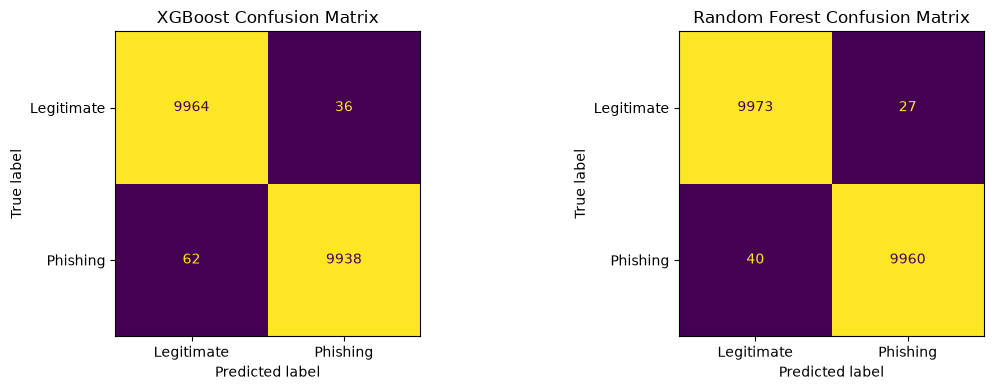

Saved.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# XGBoost confusion matrix
cm_xgb = confusion_matrix(y_test, xgb_test_pred)
ConfusionMatrixDisplay(cm_xgb, display_labels=['Legitimate', 'Phishing']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('XGBoost Confusion Matrix')

# Random Forest confusion matrix
cm_rf = confusion_matrix(y_test, rf_test_pred)
ConfusionMatrixDisplay(cm_rf, display_labels=['Legitimate', 'Phishing']).plot(ax=axes[1], colorbar=False)
axes[1].set_title('Random Forest Confusion Matrix')

plt.tight_layout()
plt.savefig('../data/branchA_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

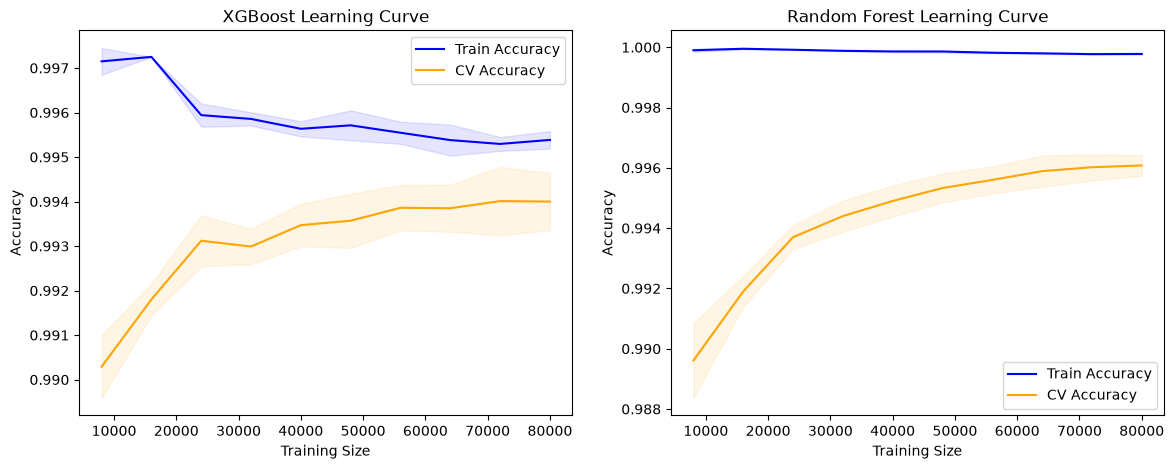

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (model, name) in enumerate([(xgb, 'XGBoost'), (rf, 'Random Forest')]):
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y,
        cv=5,
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='accuracy'
    )
    
    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    test_mean = test_scores.mean(axis=1)
    test_std = test_scores.std(axis=1)
    
    axes[idx].plot(train_sizes, train_mean, label='Train Accuracy', color='blue')
    axes[idx].fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
    axes[idx].plot(train_sizes, test_mean, label='CV Accuracy', color='orange')
    axes[idx].fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')
    
    axes[idx].set_title(f'{name} Learning Curve')
    axes[idx].set_xlabel('Training Size')
    axes[idx].set_ylabel('Accuracy')
    axes[idx].legend()

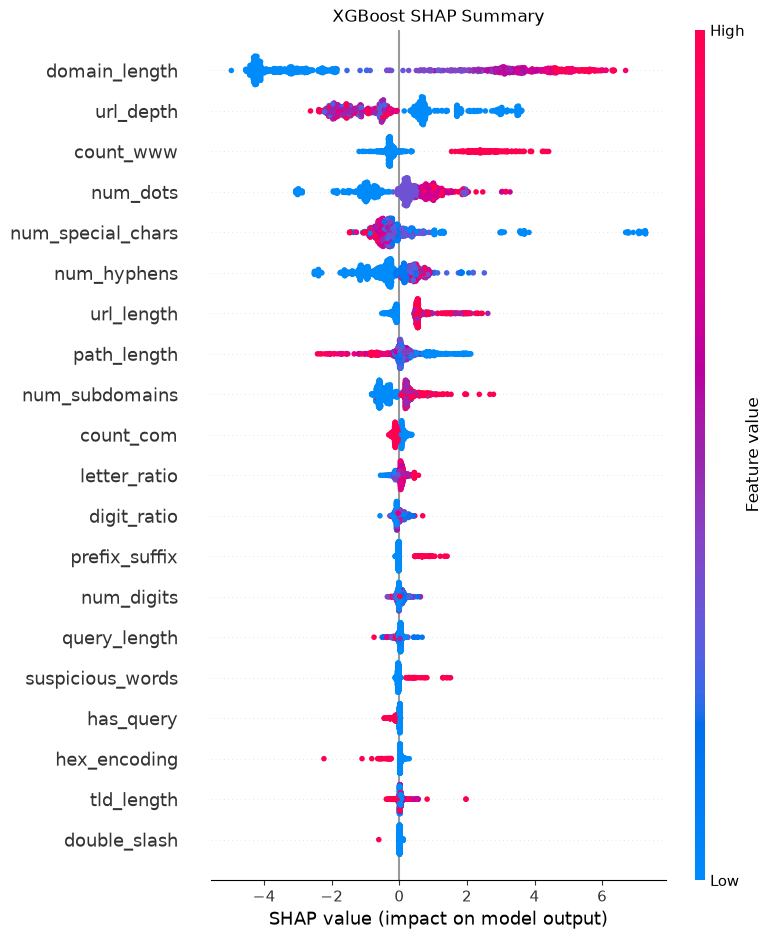

Saved.


In [11]:
import shap

# Use a sample of 1000 rows for speed
X_sample = X_test.sample(1000, random_state=42)

# SHAP explainer for XGBoost
explainer_xgb = shap.TreeExplainer(xgb)
shap_values_xgb = explainer_xgb.shap_values(X_sample)

# Summary plot
plt.figure()
shap.summary_plot(shap_values_xgb, X_sample, show=False)
plt.title('XGBoost SHAP Summary')
plt.tight_layout()
plt.savefig('../data/branchA_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

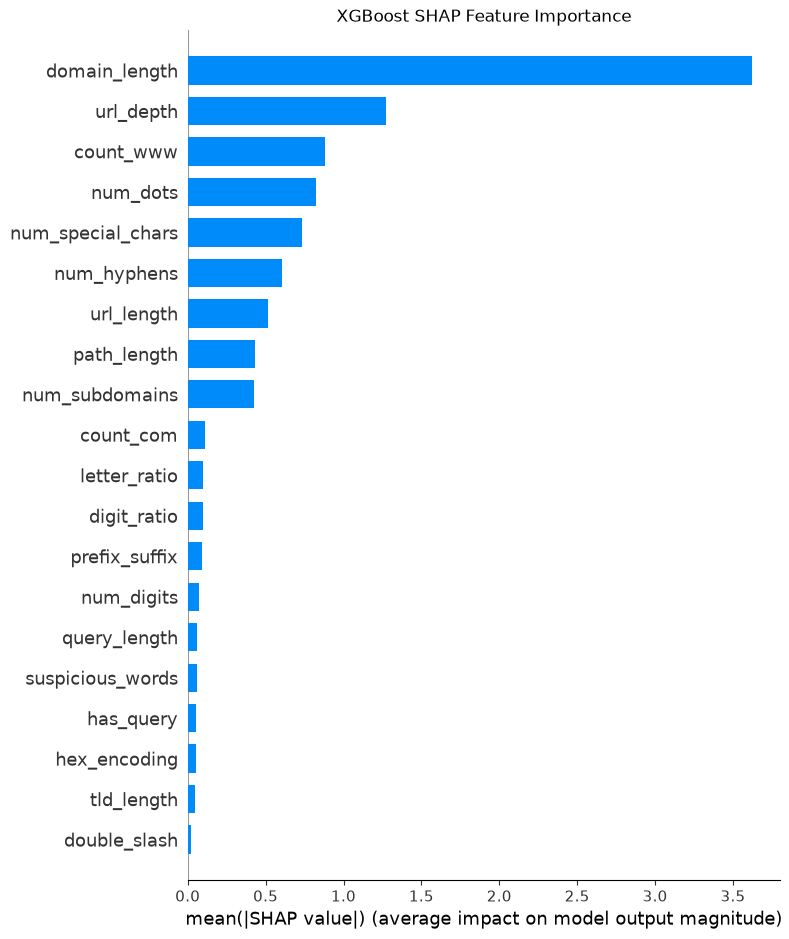

Saved.


In [12]:
# SHAP bar plot
plt.figure()
shap.summary_plot(shap_values_xgb, X_sample, plot_type='bar', show=False)
plt.title('XGBoost SHAP Feature Importance')
plt.tight_layout()
plt.savefig('../data/branchA_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [13]:
import joblib
import os

# Create models directory if not exists
os.makedirs('../models', exist_ok=True)

# Save both models
joblib.dump(xgb, '../models/branch_a_xgb.pkl')
joblib.dump(rf, '../models/branch_a_rf.pkl')

print("Models saved:")
print("  ../models/branch_a_xgb.pkl")
print("  ../models/branch_a_rf.pkl")

Models saved:
  ../models/branch_a_xgb.pkl
  ../models/branch_a_rf.pkl


In [2]:
python -m jupyter notebook notebooks/

SyntaxError: invalid syntax (3491002952.py, line 1)